In [1]:
import keras
from keras.layers import Activation, Dense, Dropout, Conv2D, Flatten, MaxPooling2D
from keras.models import Sequential
import librosa
import librosa.display
import pandas as pd
import numpy as np
import random

In [2]:
# Read Data
data = pd.read_csv("UrbanSound8K.csv")
data.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [3]:
data.shape

(8732, 8)

In [4]:
# Get data over 3s long (to get useful information)
valid_data = data[["slice_file_name","fold","classID","class"]][data["end"]-data["start"]>=3]
valid_data.shape

(7468, 4)

In [5]:
valid_data.head(10)

,slice_file_name,fold,classID,class
1,100263-2-0-117.wav,5,2,children_playing
2,100263-2-0-121.wav,5,2,children_playing
3,100263-2-0-126.wav,5,2,children_playing
4,100263-2-0-137.wav,5,2,children_playing
5,100263-2-0-143.wav,5,2,children_playing
6,100263-2-0-161.wav,5,2,children_playing
7,100263-2-0-3.wav,5,2,children_playing
8,100263-2-0-36.wav,5,2,children_playing
14,100652-3-0-0.wav,2,3,dog_bark
15,100652-3-0-1.wav,2,3,dog_bark


In [6]:
# Example of siren spectogram
y, sr = librosa.load('C:\\Users\\gaura\\Desktop\\ML\\Project\\UrbanSound8K\\audio\\fold6\\9032-3-2-0.wav',duration = 2.97)
ps = librosa.feature.melspectrogram(y=y,sr=sr)
ps.shape

(128, 40)

C:\Users\gaura\Anaconda3\envs\Tensorflow\lib\site-packages\librosa\display.py:974: MatplotlibDeprecationWarning: The 'basey' parameter of __init__() has been renamed 'base' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  scaler(mode, **kwargs)
C:\Users\gaura\Anaconda3\envs\Tensorflow\lib\site-packages\librosa\display.py:974: MatplotlibDeprecationWarning: The 'linthreshy' parameter of __init__() has been renamed 'linthresh' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  scaler(mode, **kwargs)


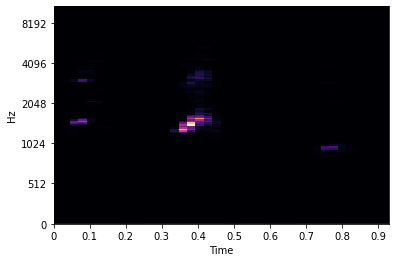

In [7]:
librosa.display.specshow(ps,y_axis = 'mel', x_axis = 'time')

In [8]:
# Example of AC Spectogram
y, sr = librosa.load('C:\\Users\\gaura\\Desktop\\ML\\Project\\UrbanSound8K\\audio\\fold1\\9031-3-1-0.wav',duration=2.97)
ps = librosa.feature.melspectrogram(y=y, sr=sr)
ps.shape

(128, 18)

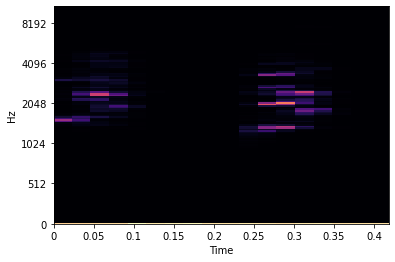

In [9]:
librosa.display.specshow(ps, y_axis= 'mel', x_axis= "time")

In [10]:
# Children playing
y, sr = librosa.load("C:\\Users\\gaura\\Desktop\\ML\\Project\\UrbanSound8K\\audio\\fold9\\13579-2-0-15.wav", duration=2.97)
ps = librosa.feature.melspectrogram(y=y, sr=sr)
ps.shape

(128, 128)

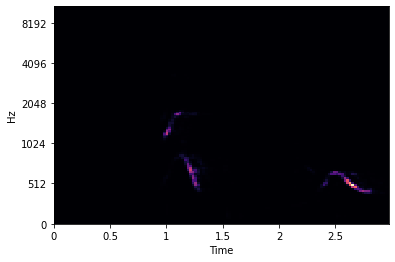

In [11]:
librosa.display.specshow(ps, y_axis= "mel", x_axis= "time" )

### Iterate over all samples in valid. For every sample create (128,128) spectrogram

In [12]:
valid_data["path"] = "fold" + valid_data["fold"].astype("str") + "/" + valid_data["slice_file_name"].astype("str")

In [13]:
dataset = [] # Dataset
for row in valid_data.itertuples():
    y, sr = librosa.load("C:\\Users\\gaura\\Desktop\\ML\\Project\\UrbanSound8K\\audio\\" + row.path, duration = 2.97)
    ps = librosa.feature.melspectrogram(y=y, sr=sr)
    if ps.shape != (128,128): continue
    dataset.append((ps, row.classID))    

In [14]:
print("No. of Samples:", len(dataset))

No. of Samples: 7466


In [15]:
random.shuffle(dataset)

train = dataset[:7000]
test = dataset[7000:]

x_train,y_train = zip(*train)#unzip
x_test,y_test = zip(*test)

# reshape for CNN input
x_train = np.array([x.reshape((128,128,1)) for x in x_train])
x_test = np.array([x.reshape((128,128,1)) for x in x_test])

# One hot Encoding
y_train = np.array(keras.utils.to_categorical(y_train,10))
y_test = np.array(keras.utils.to_categorical(y_test,10))


In [16]:
model = Sequential()
input_shape = (128,128,1)

model.add(Conv2D(24,(5,5), strides=(1,1), input_shape=input_shape))
model.add(MaxPooling2D((4,2), strides =(4,2)))
model.add(Activation("relu"))

model.add(Conv2D(48,(5,5),padding = "valid"))
model.add(MaxPooling2D((4,2), strides =(4,2)))
model.add(Activation("relu"))

model.add(Conv2D(48,(5,5), padding = "valid"))
model.add(Activation("relu"))

model.add(Flatten())
model.add(Dropout(rate=0.5))

model.add(Dense(64))
model.add(Activation("relu"))
model.add(Dropout(rate=0.5))

model.add(Dense(10))
model.add(Activation("softmax"))

In [17]:
model.compile(optimizer="Adam",loss="categorical_crossentropy", metrics=["accuracy"])

In [18]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Restrict TensorFlow to only use the fourth GPU
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')

        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

In [19]:
model.fit(x= x_train, y=y_train, epochs=14, batch_size = 128, validation_data= (x_test,y_test))

Epoch 1/14
55/55 [==============================] - 71s 1s/step - loss: 2.6811 - accuracy: 0.1977 - val_loss: 2.1751 - val_accuracy: 0.2554
Epoch 2/14
55/55 [==============================] - 70s 1s/step - loss: 2.1267 - accuracy: 0.2390 - val_loss: 2.0060 - val_accuracy: 0.2618
Epoch 3/14
55/55 [==============================] - 68s 1s/step - loss: 1.9539 - accuracy: 0.3124 - val_loss: 1.7795 - val_accuracy: 0.4120
Epoch 4/14
55/55 [==============================] - 70s 1s/step - loss: 1.8263 - accuracy: 0.3629 - val_loss: 1.6476 - val_accuracy: 0.4592
Epoch 5/14
55/55 [==============================] - 73s 1s/step - loss: 1.6668 - accuracy: 0.4104 - val_loss: 1.4923 - val_accuracy: 0.5193
Epoch 6/14
55/55 [==============================] - 70s 1s/step - loss: 1.5689 - accuracy: 0.4469 - val_loss: 1.4542 - val_accuracy: 0.5451
Epoch 7/14
55/55 [==============================] - 62s 1s/step - loss: 1.4773 - accuracy: 0.4754 - val_loss: 1.3943 - val_accuracy: 0.5494
Epoch 8/14
55/55 [==

In [20]:
score = model.evaluate(x_test, y_test)
print("Test loss:",score[0])
print("Test accuracy:", score[1])

15/15 [==============================] - 1s 79ms/step - loss: 1.0179 - accuracy: 0.6459
Test loss: 1.0179061889648438
Test accuracy: 0.6459227204322815
